[0.9942291601264011, 0.993008875417532, 0.9855719208869358]
===== SUBCRITICAL RESULTS =====
Gamma = 0.57336 ± 0.33016
R^2   = 0.99423


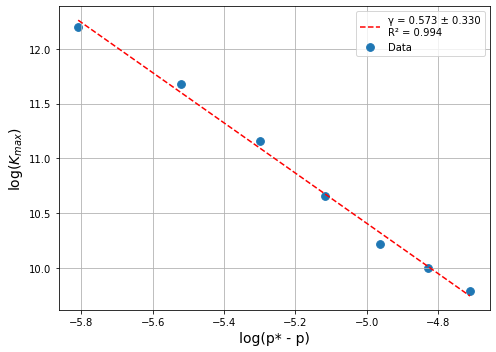

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    17826.42451,
22053.15307,
27389.73079,
42301.45545100958,
70351.11376878036,
118249.5124607959,
198236.4599101593,
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110
dpstar = 0.003

# reconstruct actual p (subcritical → p < p*)
p = pstar - p_minus_pstar

# ---------------------------
# FUNCTION: gamma + R²
# ---------------------------
def compute_gamma(pstar_val):
    delta = pstar_val - p   # (p* - p)
    
    mask = delta > 0
    
    x = np.log(delta[mask])
    y = np.log(curvature[mask])
    
    if len(x) < 2:
        return np.nan, None, None
    
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # R²
    y_fit = slope * x + intercept
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    
    return gamma, slope, r2

# ---------------------------
# CENTRAL VALUE
# ---------------------------
gamma_c, slope_c, r2_c = compute_gamma(pstar)

# ---------------------------
# ERROR FROM p*
# ---------------------------
gamma_plus, _, r2_plus = compute_gamma(pstar + dpstar)
gamma_minus, _, r2_minus = compute_gamma(pstar - dpstar)

valid = [g for g in [gamma_plus, gamma_minus] if not np.isnan(g)]
gamma_err = max(abs(g - gamma_c) for g in valid)
valid_r2 = [r for r in [r2_c, r2_plus, r2_minus] if r is not None]
r2_final = min(valid_r2)
print(valid_r2)
# ---------------------------
# FINAL FIT (central)
# ---------------------------
log_x = np.log(p_minus_pstar)
log_y = np.log(curvature)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("===== SUBCRITICAL RESULTS =====")
print(f"Gamma = {gamma_c:.5f} ± {gamma_err:.5f}")
print(f"R^2   = {r2_c:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, s=60, label="Data")
plt.plot(x_fit, y_fit, 'r--',
         label=f"γ = {gamma_c:.3f} ± {gamma_err:.3f}\nR² = {r2_c:.3f}")

plt.xlabel("log(p* - p)",fontsize=14)
plt.ylabel("$\log(K_{max})$",fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
#plt.savefig("plusfamily_CSI.pdf")
plt.show()


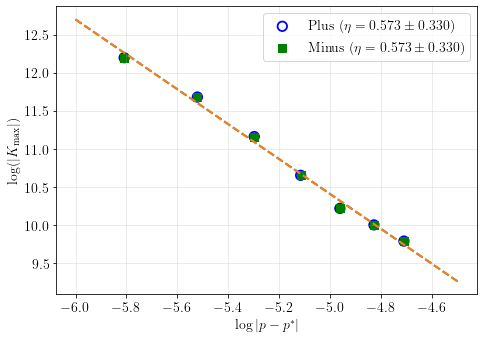

Plus family:
gamma = 0.57336 ± 0.33016

Minus family:
gamma = 0.57336 ± 0.33016


In [9]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,          # base size
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036, 118249.5124607959,
    198236.4599101593
])

delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
     42301.45545100958, 70351.11376878036,
   118249.5124607959,198236.4599101593
])

delta_minus = -np.array([
    0.009, 0.008, 0.007, 0.006, 0.005,
    0.004, 0.003
])

ddelta = 0.003

# ---------------------------
# FUNCTIONS
# ---------------------------
def compute_gamma(delta, curvature):
    delta = np.abs(delta)
    x = np.log(delta)
    y = np.log(curvature)

    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4

    return gamma, slope, intercept


def gamma_with_shift(delta, curvature, ddelta):
    g_c, slope, intercept = compute_gamma(delta, curvature)

    g_list = []

    for shift in [+ddelta, -ddelta]:
        d_new = np.abs(delta + shift)
        mask = d_new > 0

        if np.sum(mask) < 2:
            continue

        g, _, _ = compute_gamma(d_new[mask], curvature[mask])
        g_list.append(g)

    g_err = max(abs(g - g_c) for g in g_list)

    return g_c, g_err, slope, intercept


# ---------------------------
# COMPUTE
# ---------------------------
gp, err_p, sp, ip = gamma_with_shift(delta_plus, curvature_plus, ddelta)
gm, err_m, sm, im = gamma_with_shift(delta_minus, curvature_minus, ddelta)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

# Scatter points
# Plus (smaller + transparent)
plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', s=90,
            facecolors='none', edgecolors='blue', linewidth=1.8,
            label=f"Plus ($\\eta={gp:.3f} \\pm {err_p:.3f}$)")

# Minus → filled squares
plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', s=50, color='green',
            label=f"Minus ($\\eta={gm:.3f} \\pm {err_m:.3f}$)")

x_fit = np.linspace(-6, -4.5, 200)

plt.plot(x_fit, sp*x_fit + ip, '--', linewidth=2)
plt.plot(x_fit, sm*x_fit + im, '--', linewidth=2)

# Labels
plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(|K_{\max}|)$", fontsize=14)

# Style
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig("separate_scaling_new.pdf", dpi=300)

plt.show()

# ---------------------------
# PRINT
# ---------------------------
print("Plus family:")
print(f"gamma = {gp:.5f} ± {err_p:.5f}")

print("\nMinus family:")
print(f"gamma = {gm:.5f} ± {err_m:.5f}")

In [10]:
import numpy as np

# Your original data
delta = np.abs(delta_plus)
curvature = curvature_plus

# Original fit
x = np.log(delta)
y = np.log(curvature)
slope_original, _ = np.polyfit(x, y, 1)
gamma_original = -slope_original / 4

# Bootstrap
n_bootstrap = 1000
gamma_values = []

for i in range(n_bootstrap):
    # Randomly pick 7 indices WITH replacement
    indices = np.random.choice(len(delta), size=len(delta), replace=True)
    
    # Resample your data
    x_resample = x[indices]
    y_resample = y[indices]
    
    # Fit and compute gamma
    slope, _ = np.polyfit(x_resample, y_resample, 1)
    gamma = -slope / 4
    gamma_values.append(gamma)

# Error = standard deviation of all bootstrap gammas
gamma_error = np.std(gamma_values)

print(f"γ = {gamma_original:.5f} ± {gamma_error:.5f}")

γ = 0.57336 ± 0.02570


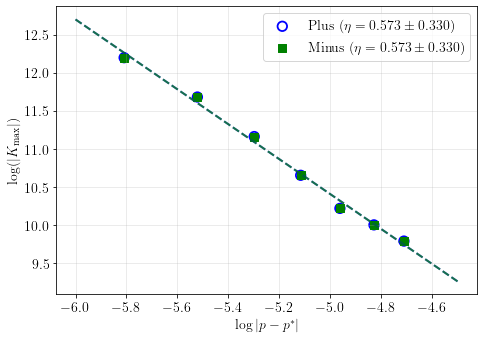

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036, 118249.5124607959,
    198236.4599101593
])
delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036,
    118249.5124607959, 198236.4599101593
])
delta_minus = np.array([
    -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003
])

# Uncertainty in p*
delta_uncertainty = 0.003

# ---------------------------
# FUNCTIONS
# ---------------------------
def compute_gamma(delta, curvature):
    """Compute gamma from log-log fit"""
    delta_abs = np.abs(delta)
    x = np.log(delta_abs)
    y = np.log(curvature)
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    return gamma, slope, intercept

def gamma_with_pstar_error(delta, curvature, delta_err):
    """
    Propagate uncertainty in p* to uncertainty in gamma
    
    delta: δ = p - p* values
    curvature: K_max values
    delta_err: uncertainty in p* (which becomes uncertainty in δ)
    """
    # Central value
    gamma_central, slope, intercept = compute_gamma(delta, curvature)
    
    # If p* is smaller by delta_err, then δ increases by delta_err
    delta_upper = delta + delta_err * np.sign(delta)
    gamma_upper, _, _ = compute_gamma(delta_upper, curvature)
    
    # If p* is larger by delta_err, then δ decreases by delta_err
    delta_lower = delta - delta_err * np.sign(delta)
    # Need to check if any deltas cross zero
    if np.any(np.abs(delta_lower) < 1e-10):
        # Use one-sided error
        gamma_err = abs(gamma_upper - gamma_central)
    else:
        gamma_lower, _, _ = compute_gamma(delta_lower, curvature)
        gamma_err = max(abs(gamma_upper - gamma_central), 
                       abs(gamma_lower - gamma_central))
    
    return gamma_central, gamma_err, slope, intercept

# ---------------------------
# COMPUTE
# ---------------------------
gp, err_p, sp, ip = gamma_with_pstar_error(delta_plus, curvature_plus, delta_uncertainty)
gm, err_m, sm, im = gamma_with_pstar_error(delta_minus, curvature_minus, delta_uncertainty)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', s=90,
            facecolors='none', edgecolors='blue', linewidth=1.8,
            label=f"Plus ($\\eta={gp:.3f} \\pm {err_p:.3f}$)")

plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', s=50, color='green',
            label=f"Minus ($\\eta={gm:.3f} \\pm {err_m:.3f}$)")

x_fit = np.linspace(-6, -4.5, 200)
plt.plot(x_fit, sp*x_fit + ip, '--', linewidth=2, color='blue', alpha=0.7)
plt.plot(x_fit, sm*x_fit + im, '--', linewidth=2, color='green', alpha=0.7)

plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(|K_{\max}|)$", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("separate_scaling_new.pdf", dpi=300)
plt.show()

# ---------------------------
# PRINT
# ------------------

Plus family:
p*		γ
------------------------------
4.108		0.79553
4.109		0.68585
4.11		0.57336
4.111		0.45555
4.112		0.32468

Result: γ = 0.57336 ± 0.16585


Minus family:
p*		γ
------------------------------
4.108		0.32468
4.109		0.45555
4.11		0.57336
4.111		0.68585
4.112		0.79553

Result: γ = 0.57336 ± 0.16585


FINAL RESULTS:
Plus family:  γ = 0.57336 ± 0.16585
Minus family: γ = 0.57336 ± 0.16585


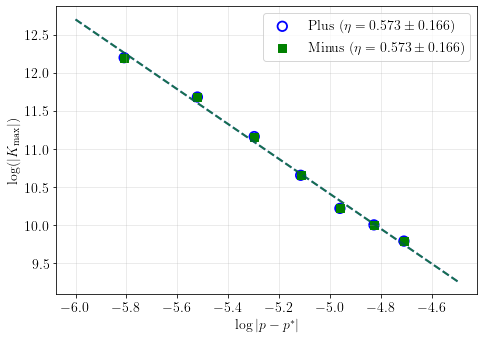

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036, 118249.5124607959,
    198236.4599101593
])
delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036,
    118249.5124607959, 198236.4599101593
])
delta_minus = np.array([
    -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003
])

# ---------------------------
# FUNCTION
# ---------------------------
def compute_gamma(delta, curvature):
    delta_abs = np.abs(delta)
    x = np.log(delta_abs)
    y = np.log(curvature)
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    return gamma, slope, intercept

# ---------------------------
# SCAN 5 P* VALUES
# ---------------------------
pstar_values = [4.108, 4.109, 4.110, 4.111, 4.112]

print("Plus family:")
print("p*\t\tγ")
print("-" * 30)
gammas_plus = []
slopes_plus = []
intercepts_plus = []
for pstar in pstar_values:
    # Shift delta by the change in p*
    delta_shifted = delta_plus + (4.110 - pstar)
    gamma, slope, intercept = compute_gamma(delta_shifted, curvature_plus)
    gammas_plus.append(gamma)
    slopes_plus.append(slope)
    intercepts_plus.append(intercept)
    print(f"{pstar}\t\t{gamma:.5f}")

gamma_plus_central = gammas_plus[2]  # p* = 4.110
slope_plus_central = slopes_plus[2]
intercept_plus_central = intercepts_plus[2]
gamma_plus_err = np.std(gammas_plus)

print(f"\nResult: γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}")

print("\n" + "="*50)
print("\nMinus family:")
print("p*\t\tγ")
print("-" * 30)
gammas_minus = []
slopes_minus = []
intercepts_minus = []
for pstar in pstar_values:
    delta_shifted = delta_minus + (4.110 - pstar)
    gamma, slope, intercept = compute_gamma(delta_shifted, curvature_minus)
    gammas_minus.append(gamma)
    slopes_minus.append(slope)
    intercepts_minus.append(intercept)
    print(f"{pstar}\t\t{gamma:.5f}")

gamma_minus_central = gammas_minus[2]  # p* = 4.110
slope_minus_central = slopes_minus[2]
intercept_minus_central = intercepts_minus[2]
gamma_minus_err = np.std(gammas_minus)

print(f"\nResult: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}")

print("\n" + "="*50)
print("\nFINAL RESULTS:")
print("="*50)
print(f"Plus family:  γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}")
print(f"Minus family: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

# Scatter points (using central p* = 4.110)
plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', s=90,
            facecolors='none', edgecolors='blue', linewidth=1.8,
            label=f"Plus ($\\eta={gamma_plus_central:.3f} \\pm {gamma_plus_err:.3f}$)")

plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', s=50, color='green',
            label=f"Minus ($\\eta={gamma_minus_central:.3f} \\pm {gamma_minus_err:.3f}$)")

# Fit lines
x_fit = np.linspace(-6, -4.5, 200)
plt.plot(x_fit, slope_plus_central*x_fit + intercept_plus_central, 
         '--', linewidth=2, color='blue', alpha=0.7)
plt.plot(x_fit, slope_minus_central*x_fit + intercept_minus_central, 
         '--', linewidth=2, color='green', alpha=0.7)

# Labels
plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(|K_{\max}|)$", fontsize=14)

# Style
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig("separate_scaling_new.pdf", dpi=300)
plt.show()

Plus family:
p*		γ		R²
--------------------------------------------------
4.108		0.79553		0.994000
4.109		0.68585		0.994648
4.11		0.57336		0.994229
4.111		0.45555		0.990425
4.112		0.32468		0.972829

Result: γ = 0.57336 ± 0.16585
R² (central): 0.994229
R² (minimum): 0.972829


Minus family:
p*		γ		R²
--------------------------------------------------
4.108		0.32468		0.972829
4.109		0.45555		0.990425
4.11		0.57336		0.994229
4.111		0.68585		0.994648
4.112		0.79553		0.994000

Result: γ = 0.57336 ± 0.16585
R² (central): 0.994229
R² (minimum): 0.972829


FINAL RESULTS:
Plus family:  γ = 0.57336 ± 0.16585, R² ≥ 0.9728
Minus family: γ = 0.57336 ± 0.16585, R² ≥ 0.9728


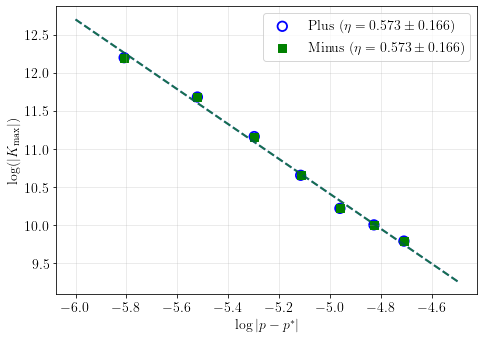

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036, 118249.5124607959,
    198236.4599101593
])
delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    42301.45545100958, 70351.11376878036,
    118249.5124607959, 198236.4599101593
])
delta_minus = np.array([
    -0.009, -0.008, -0.007, -0.006, -0.005, -0.004, -0.003
])

# ---------------------------
# FUNCTION
# ---------------------------
def compute_gamma_with_r2(delta, curvature):
    delta_abs = np.abs(delta)
    x = np.log(delta_abs)
    y = np.log(curvature)
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # Calculate R²
    y_pred = slope * x + intercept
    r_squared = pearsonr(y, y_pred)[0]**2
    
    return gamma, slope, intercept, r_squared

# ---------------------------
# SCAN 5 P* VALUES
# ---------------------------
pstar_values = [4.108, 4.109, 4.110, 4.111, 4.112]

print("Plus family:")
print("p*\t\tγ\t\tR²")
print("-" * 50)
gammas_plus = []
slopes_plus = []
intercepts_plus = []
r2_plus = []
for pstar in pstar_values:
    delta_shifted = delta_plus + (4.110 - pstar)
    gamma, slope, intercept, r2 = compute_gamma_with_r2(delta_shifted, curvature_plus)
    gammas_plus.append(gamma)
    slopes_plus.append(slope)
    intercepts_plus.append(intercept)
    r2_plus.append(r2)
    print(f"{pstar}\t\t{gamma:.5f}\t\t{r2:.6f}")

gamma_plus_central = gammas_plus[2]
slope_plus_central = slopes_plus[2]
intercept_plus_central = intercepts_plus[2]
r2_plus_central = r2_plus[2]
gamma_plus_err = np.std(gammas_plus)
r2_plus_min = np.min(r2_plus)

print(f"\nResult: γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}")
print(f"R² (central): {r2_plus_central:.6f}")
print(f"R² (minimum): {r2_plus_min:.6f}")

print("\n" + "="*50)
print("\nMinus family:")
print("p*\t\tγ\t\tR²")
print("-" * 50)
gammas_minus = []
slopes_minus = []
intercepts_minus = []
r2_minus = []
for pstar in pstar_values:
    delta_shifted = delta_minus + (4.110 - pstar)
    gamma, slope, intercept, r2 = compute_gamma_with_r2(delta_shifted, curvature_minus)
    gammas_minus.append(gamma)
    slopes_minus.append(slope)
    intercepts_minus.append(intercept)
    r2_minus.append(r2)
    print(f"{pstar}\t\t{gamma:.5f}\t\t{r2:.6f}")

gamma_minus_central = gammas_minus[2]
slope_minus_central = slopes_minus[2]
intercept_minus_central = intercepts_minus[2]
r2_minus_central = r2_minus[2]
gamma_minus_err = np.std(gammas_minus)
r2_minus_min = np.min(r2_minus)

print(f"\nResult: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}")
print(f"R² (central): {r2_minus_central:.6f}")
print(f"R² (minimum): {r2_minus_min:.6f}")

print("\n" + "="*50)
print("\nFINAL RESULTS:")
print("="*50)
print(f"Plus family:  γ = {gamma_plus_central:.5f} ± {gamma_plus_err:.5f}, R² ≥ {r2_plus_min:.4f}")
print(f"Minus family: γ = {gamma_minus_central:.5f} ± {gamma_minus_err:.5f}, R² ≥ {r2_minus_min:.4f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', s=90,
            facecolors='none', edgecolors='blue', linewidth=1.8,
            label=f"Plus ($\\eta={gamma_plus_central:.3f} \\pm {gamma_plus_err:.3f})$")

plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', s=50, color='green',
            label=f"Minus ($\\eta={gamma_minus_central:.3f} \\pm {gamma_minus_err:.3f}$)")

x_fit = np.linspace(-6, -4.5, 200)
plt.plot(x_fit, slope_plus_central*x_fit + intercept_plus_central, 
         '--', linewidth=2, color='blue', alpha=0.7)
plt.plot(x_fit, slope_minus_central*x_fit + intercept_minus_central, 
         '--', linewidth=2, color='green', alpha=0.7)

plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(|K_{\max}|)$", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("separate_scaling_new.pdf", dpi=300)
plt.show()